# Distribuția uniformă

Laboratorul 2, DEPI

# 1. Obiectiv

Generarea de eșantioane uniforme în Matlab, reprezentare prin histograme
și studierea efectelor parametrilor. Calcularea probabilităților
teoretice și compararea cu estimările obținute din eșantioane.

# 2. Aspecte teoretice

## 2.1 Funcția densitate de probabilitate

În acest laborator considerăm **variabile aleatoare continue**.

O variabilă aleatoare continuă $A$ este descrisă de o **funcție
densitate de probabilitate** $w_A(x)$, care descrie modul în care
probabilitatea este distribuită între valorile posibile. Probabilitatea
unui interval se obține prin integrarea funcției densitate de
probabilitate, nu prin evaluarea ei într-un singur punct.

Probabilitatea ca $A$ să se afle în intervalul $[a,b]$ este **aria de
sub funcția densitate de probabilitate** pe acel interval, adică
integrala funcției densitate de probabilitate de la $a$ la $b$:

$$P(a<A\le b)=\int_a^b w_A(x)\,dx,$$

Doar intervalele au probabilitate nenulă. Probabilitatea ca $A$ să fie
exact egală cu o anumită valoare este întotdeauna zero.

<figure>
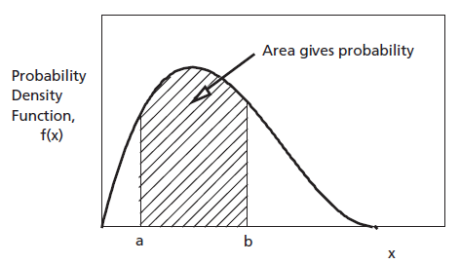
<figcaption aria-hidden="true">Probabilitatea = Aria de sub funcția
densitate de probabilitate</figcaption>
</figure>

Funcția densitate de probabilitate satisface întotdeauna $w_A(x)\ge 0$,
iar integrala ei este 1, dar valorile ei pot fi mai mari decât 1.

**Funcția de repartiție (FR)** este definită ca probabilitatea ca
$A \le x$:

$$
F_A(x)=P(A\le x)
$$

FR este nedescrescătoare și ia valori între 0 și 1.

FR poate fi folosită și pentru a calcula probabilități pe intervale:

$$
P(a<A\le b)=F_A(b)-F_A(a).
$$

Cele două funcții sunt legate. Funcția densitate de probabilitate este
derivata FR:

$$
w_A(x)=\frac{dF_A(x)}{dx} \qquad \qquad F_A(x)=\int_{-\infty}^{x} w_A(t)\,dt.
$$

### Eșantioane aleatoare

Un vector de $N$ valori generate dintr-o distribuție este un **eșantion
aleator**:

$$x = [x_1, x_2, \ldots, x_N].$$

Valorile se schimbă la fiecare rulare, dar comportamentul lor statistic
ar trebui să rămână același.

Media și varianța (sau deviația standard) calculate pentru un vector de
valori sunt numite **media eșantionului** și **varianța eșantionului**
(sau deviația standard).

``` matlab
% Media, deviația standard și varianța eșantionului
sample_mean = mean(x)
sample_std = std(x)
sample_var = var(x)
```

Media și varianța eșantionului sunt apropiate, dar nu exact egale cu
media și varianța teoretice ale distribuției (sunt „estimări” ale
acestor valori teoretice).

## 2.2 Distribuția uniformă

### Definiție și parametri

Distribuția uniformă descrie o variabilă aleatoare care are șanse egale
de a lua orice valoare dintr-un interval dat $[a,b]$.

Se notează:

$$A \sim \mathcal{U}[a,b], \qquad \textrm{  cu  } a < b.$$

Funcția sa densitate de probabilitate este definită prin:

$$
w_A(x) =
\begin{cases}
\dfrac{1}{b-a}, & a \le x \le b, \\
0, & \text{în rest}.
\end{cases}
$$

Funcția densitate de probabilitate este constantă pe $[a,b]$.

<figure>
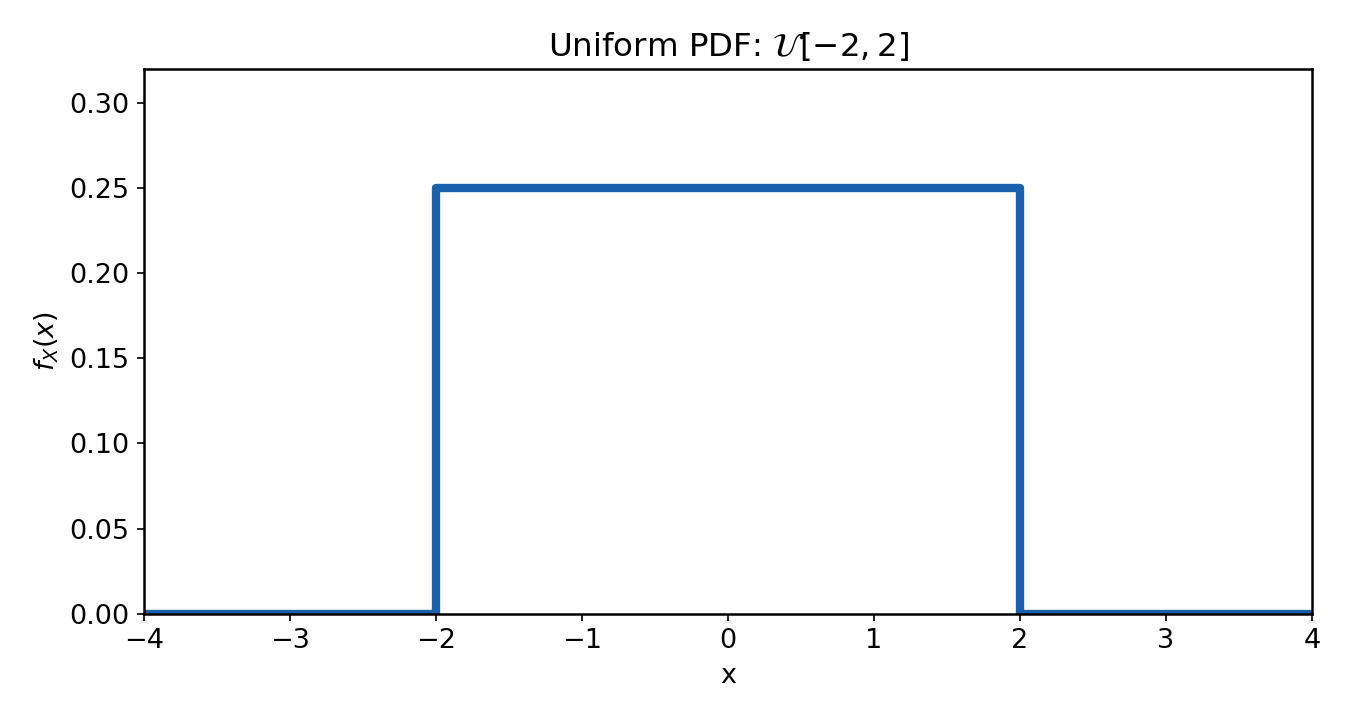
<figcaption aria-hidden="true">Funcția densitate de probabilitate pentru
<span class="math inline">𝒰[−2, 2]</span>.</figcaption>
</figure>

Media statistică și varianța sunt

$$
\mathrm{E}\{A\} = \frac{a+b}{2},
\qquad
\sigma_A^2 = \frac{(b-a)^2}{12}.
$$

### Generarea eșantioanelor uniforme în Matlab

`rand()` generează valori uniforme cu $0<A<1$. Nu contează dacă limitele
$0$ și $1$ sunt incluse sau nu, deoarece în interval există oricum o
infinitate de valori.

``` matlab
A = rand()          % o valoare din U[0,1]

A = rand(1, 10)     % vector linie cu 10 valori independente din U[0,1]
```

Pentru a obține valori dintr-un interval general $[a,b]$, scalați și
deplasați valorile:

$$B = a + (b-a)A, \qquad A \sim \mathcal{U}[0,1].$$

``` matlab
a = 5;
b = 7;
N = 1000;

x_uniform = a + (b-a)*rand(1, N);
```

Aici, $b-a$ stabilește lățimea intervalului, iar $a$ stabilește limita
inferioară.

### Probabilități pentru distribuția uniformă

Probabilitățile sunt arii de sub funcția densitate de probabilitate.

Pentru o variabilă uniformă, calculul probabilităților se reduce la
calculul ariei unui dreptunghi și se poate realiza ușor.

Exemplu: pentru $X \sim \mathcal{U}[2, 10]$, probabilitatea ca $X$ să
fie între 3 și 5 este $\frac{2}{8} = 0.25$.

## 2.3 Histograme pentru vizualizarea distribuțiilor

O **histogramă** grupează valorile eșantionului în intervale (“bins”).
Înălțimea fiecărei bare este numărul de valori din intervalul respectiv:

``` matlab
x = -4 + 14*rand(1, 10000);
histogram(x, 30)
xlabel('Valoare')
ylabel('Număr de valori')
grid on
```

Folosiți `figure` pentru a deschide o fereastră nouă înainte de a
reprezenta altă histogramă. Numărul de intervale controlează nivelul de
detaliu: mai multe intervale oferă mai multe detalii, dar vor fi mai
puține valori în fiecare interval și, deci, înălțimi mai neregulate ale
barelor.

Pentru comparația cu o funcție densitate de probabilitate, folosiți
`'Normalization','pdf'`:

``` matlab
figure
histogram(x, 30, 'Normalization', 'pdf')
xlabel('Valoare')
ylabel('Densitate de probabilitate estimată')
grid on
```

Cu această opțiune, înălțimea fiecărei bare este numărul de valori din
clasă împărțit la numărul total de valori și la lățimea clasei. **Aria
totală a barelor**, nu suma înălțimilor, este 1, în mod similar cu o
funcție densitate de probabilitate teoretică.

Pentru un eșantion de lungime mare, înălțimile barelor ar trebui să fie
apropiate de valoarea teoretică $1/(b-a)$.

## 2.4 Estimarea probabilităților din eșantioane

Se poate estima o probabilitate dintr-un vector de eșantioane, numărând
valorile care satisfac condiția și împărțind la numărul total. De
exemplu, pentru a estima $P(-1 \le A \le 3)$ dintr-un vector de
eșantioane `x`:

``` matlab
p_estimated = sum(x >= -1 & x <= 3)/numel(x);
```

Explicație: comparațiile $x >= -1$ și $x <= 3$ produc vectori logici,
iar operatorul `&` combină cele două condiții. `sum()` numără elementele
adevărate din vectorul rezultat, iar `numel()` întoarce numărul total de
valori din vector.

Eșantioane generate diferit dau estimări diferite. Eșantioanele mai mari
oferă, în general, estimări mai precise, dar îmbunătățirea nu este
garantată la fiecare rulare.

## 2.5 Rezumat: funcții și notații pe care trebuie să le cunoașteți

| Sintaxă sau notație | Exemplu | Descriere |
|------------------------|------------------------|------------------------|
| $w_A(x)$ | $P(c<A\le d)=\int_c^d w_A(x)\,dx$ | Densitate de probabilitate; probabilitatea unui interval este o arie |
| $F_A(x)$ | $F_A(x)=P(A\le x)$ | Funcția de repartiție (FR) |
| $A\sim\mathcal{U}[a,b]$ | $A\sim\mathcal{U}[-4,10]$ | Distribuție uniformă pe $[a,b]$ |
| `rand(m,n)` | `rand(1,1000)` | $m\times n$ valori uniforme pe $[0,1]$ |
| `a + (b-a)*rand(m,n)` | `-4 + 14*rand(1,1000)` | Valori uniforme pe $[a,b]$ |
| `mean(x)`, `std(x)`, `var(x)` | `mean(x)` | Media, deviația standard și varianța eșantionului |
| `histogram(x,n)` | `histogram(x,30)` | Histogramă cu `n` clase; adăugați `'Normalization','pdf'` pentru arie unitară |
| `figure` | `figure` | Deschide o fereastră nouă pentru figuri |
| `sum(condition)/numel(x)` | `sum(x > 7)/numel(x)` | Probabilitate empirică |

# 3. Exerciții teoretice

1.  Fie $A$ o variabilă aleatoare continuă cu distribuția uniformă
    $\mathcal{U}[0, \; 6]$

    1.  Desenați funcția densitate de probabilitate a lui $A$.
    2.  Calculați probabilitatea $P(A > 2.7)$.
    3.  Calculați probabilitatea $P(A \in (0, \; 2.3))$.
    4.  Desenați funcția de repartiție $F_A(x)$ și scrieți expresia sa
        matematică.
    5.  Care este distribuția variabilei aleatoare $B$ definite prin
        $B = A - 2$?
    6.  Care este distribuția variabilei aleatoare $C$ definite prin
        $C = 3*A$?

# 4. Exerciții

Scrieți singuri toate comenzile într-un script sau live script.
Etichetați figurile și răspundeți la întrebările de interpretare în
comentarii.

1.  Eșantioane aleatoare uniforme:

    1.  Generați $N=10000$ valori din $\mathcal{U}[-4,10]$ și stocați-le
        în `x_uniform`.
    2.  Afișați minimul și maximul. Sunt egale cu limitele intervalului?
    3.  Calculați media eșantionului și comparați-o cu $(a+b)/2$.
    4.  Reprezentați primele 100 de valori. Folosiți indicele valorii pe
        axa orizontală.

2.  Histograme:

    1.  Reprezentați o histogramă a lui `x_uniform` cu 30 de clase.
    2.  Într-o figură nouă, reprezentați o histogramă cu 30 de clase,
        normalizată ca densitate de probabilitate. Comparați înălțimile
        barelor cu densitatea teoretică $1/(b-a)$.
    3.  Repetați cu 10 și 100 de clase. Ce se schimbă? Care histogramă
        este mai neregulată?
    4.  Generați un vector nou cu $N=100$ și repetați histograma cu 30
        de clase normalizată ca densitate de probabilitate. Comparați-o
        cu cea pentru $N=10000$.

3.  Efectul intervalului:

    1.  Generați câte 10000 de valori din $\mathcal{U}[0,1]$,
        $\mathcal{U}[5,6]$, și $\mathcal{U}[5,7]$.
    2.  Reprezentați histograme normalizate ca densitate de
        probabilitate, cu 30 de clase, în figuri separate.
    3.  Comparați poziția, lățimea și înălțimea. Care pereche diferă
        doar printr-o deplasare?
    4.  Calculați media fiecărui eșantion și comparați-o cu valoarea sa
        teoretică.

4.  Probabilități pentru o variabilă uniformă:

    Fie $A\sim\mathcal{U}[-4,10]$.

    1.  Calculați teoretic $P(-1\le A\le 3)$ și $P(A>7)$.
    2.  Estimați ambele probabilități din `x_uniform` folosind
        comparații logice și `sum()`.
    3.  Repetați cu $N=100$, $1000$ și $100000$. Comparați estimările cu
        teoria.
    4.  Repetați experimentul. Eșantionul cel mai mare dă întotdeauna
        estimarea cea mai apropiată?

## 4.1 Exercițiu suplimentar

1.  Scrieți `p = myCDF(v, x)` pentru a estima $P(V\le x)$ ca proporția
    valorilor din `v` care sunt mai mici sau egale cu `x`.

    1.  Pentru $A\sim\mathcal{U}[-4,10]$, scrieți FR teoretică în
        interiorul și în exteriorul intervalului.
    2.  Generați 10000 de valori. Evaluați `myCDF` în 100 de puncte de
        la $-6$ la $12$ folosind o buclă `for`.
    3.  Reprezentați împreună FR estimată și cea teoretică.

# 5. Întrebări finale

1.  O funcție densitate de probabilitate uniformă pe un interval scurt
    poate fi mai mare decât 1. De ce acest lucru nu implică o
    probabilitate mai mare decât 1?
2.  Poate o clasă goală din histogramă să demonstreze că probabilitatea
    reală a acelui interval este zero?
3.  Dacă dublați numărul de valori, dar păstrați aceleași limite ale
    claselor, ce ar trebui să se întâmple cu o histogramă de numărare?
    Dar cu una normalizată ca densitate de probabilitate?
4.  Pot două histograme ale aceluiași vector să arate foarte diferit? Ce
    ați verifica înainte de a concluziona că distribuțiile lor diferă?